# Signal Generation Utilities

Generating synthetic signals is a foundational skill for digital signal processing (DSP), sonar algorithm development, and debugging. These tools help you test, benchmark, and visualize your DSP pipeline even without real-world data.

## Common Signal Types:

- **Chirp**: A sinusoidal signal whose frequency increases (up-chirp) or decreases (down-chirp) over time. Used in sonar/radar for pulse compression and time-frequency analysis.  
    - *Why useful?* Chirps are robust in noisy environments and are a classic waveform for matched filtering and resolution studies.

- **Pulse**: A rectangular or shaped “on/off” burst, often used as the simplest model of a sonar or radar ping.
    - *Why useful?* Simulates simple targets or events. Good for testing detection algorithms and time-of-flight calculations.

- **Multi-sine**: The sum of several sine waves at different frequencies.
    - *Why useful?* Lets you see how filters, FFTs, or detection algorithms respond to multiple frequency components (e.g., interference or harmonics).

- **White Noise**: A signal where all frequencies are equally present (“flat” spectrum).
    - *Why useful?* Models real-world sensor and environmental noise, necessary for SNR/detection benchmarks.

---

**How to use these:**  
- Build synthetic test cases for your DSP chain  
- Train or test detection, classification, and filtering routines  
- Demo your toolbox in interviews or on GitHub

---


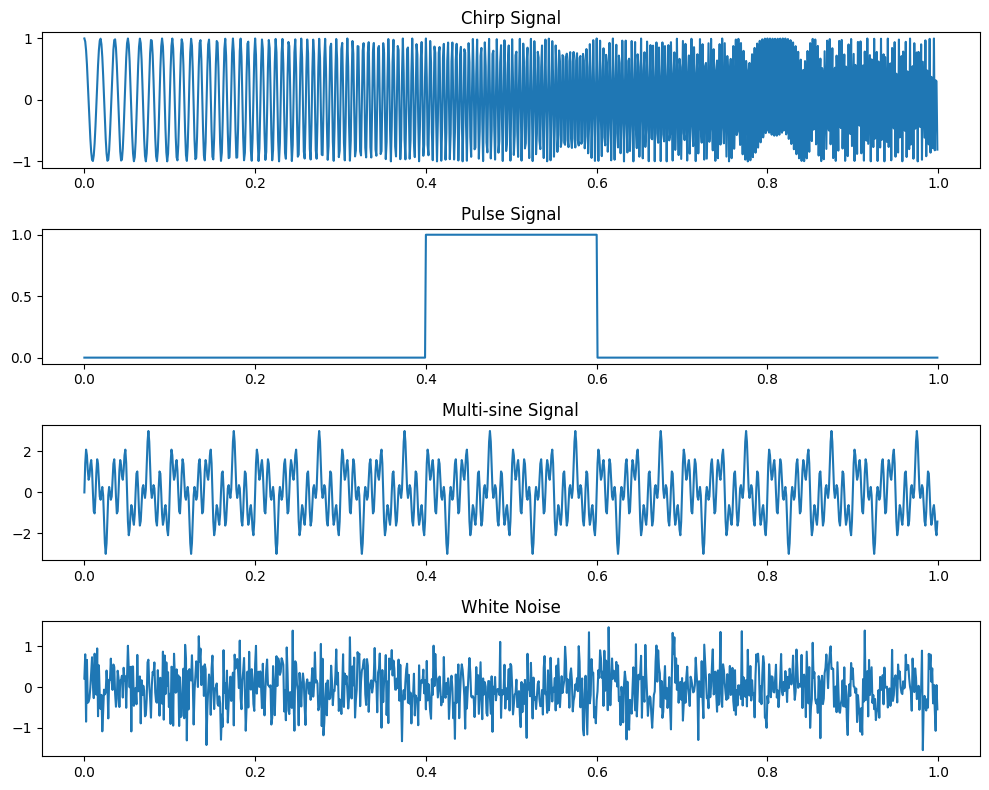

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import chirp

def make_chirp(t, f0, f1, t1, method='linear'):
    """Generate a linear or quadratic chirp."""
    return chirp(t, f0=f0, f1=f1, t1=t1, method=method)

def make_pulse(t, width=0.05, delay=0.1):
    """Simple rectangular pulse (1 during [delay, delay+width], else 0)."""
    return np.where((t >= delay) & (t < delay+width), 1.0, 0.0)

def make_multisine(t, freqs):
    """Sum of sinusoids at given frequencies."""
    return sum(np.sin(2*np.pi*f*t) for f in freqs)

def make_white_noise(size, std=1.0):
    """White Gaussian noise."""
    return np.random.randn(size) * std

# --- DEMOS ---
fs = 1000
t = np.linspace(0, 1, fs, endpoint=False)
sig_chirp = make_chirp(t, 50, 400, t1=1)
sig_pulse = make_pulse(t, width=0.2, delay=0.4)
sig_multisine = make_multisine(t, [30, 70, 150])
sig_noise = make_white_noise(len(t), std=0.5)

plt.figure(figsize=(10,8))
plt.subplot(4,1,1)
plt.plot(t, sig_chirp); plt.title('Chirp Signal')
plt.subplot(4,1,2)
plt.plot(t, sig_pulse); plt.title('Pulse Signal')
plt.subplot(4,1,3)
plt.plot(t, sig_multisine); plt.title('Multi-sine Signal')
plt.subplot(4,1,4)
plt.plot(t, sig_noise); plt.title('White Noise')
plt.tight_layout()
plt.show()
